In [1]:
from scipy.stats import norm
import scipy.io as sio
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy.io as sio
import numpy as np
def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

########################################################################check SF3 in large scale ####################################
def sliding_window(total_length, window_size, step=1):
    """
    生成正确的滑动窗口切片（从0开始计数）
    """
    slices = []
    for start in range(0, total_length - window_size + 1, step):
        end = start + window_size - 1  # 结束索引是包含的
        slices.append((start, end))
    return slices
    
# 
from tqdm import tqdm
def check_SF3_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF3_L_tb=0
    SF3_T_tb=0
    SF3_L_lr=0
    SF3_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF3_L_tb=SF3_L_tb+dv**3
        SF3_T_tb=SF3_T_tb+dv*(du**2)
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF3_L_lr=SF3_L_lr+du**3
        SF3_T_lr=SF3_T_lr+du*(dv**2)
    
    SF3_L_tb=np.nanmean(SF3_L_tb/len(slices))
    SF3_T_tb=np.nanmean(SF3_T_tb/len(slices))
    SF3_L_lr=np.nanmean(SF3_L_lr/len(slices))
    SF3_T_lr=np.nanmean(SF3_T_lr/len(slices))
    R=xscale*window_size
    SF3_check=(SF3_L_tb+SF3_T_tb+SF3_L_lr+SF3_T_lr)/2
    return SF3_check, SF3_L_tb, SF3_T_tb, SF3_L_lr, SF3_T_lr,R


def check_SF1_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF1_L_tb=0
    SF1_T_tb=0
    SF1_L_lr=0
    SF1_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF1_L_tb=SF1_L_tb+dv
        SF1_T_tb=SF1_T_tb+du
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF1_L_lr=SF1_L_lr+du
        SF1_T_lr=SF1_T_lr+dv
    
    SF1_L_tb=np.nanmean(SF1_L_tb/len(slices))
    SF1_T_tb=np.nanmean(SF1_T_tb/len(slices))
    SF1_L_lr=np.nanmean(SF1_L_lr/len(slices))
    SF1_T_lr=np.nanmean(SF1_T_lr/len(slices))
    R=xscale*window_size
    SF1_L_check=(SF1_L_tb+SF1_L_lr)/2
    SF1_T_check=(SF1_T_tb+SF1_T_lr)/2
    return SF1_L_check, SF1_T_check,R

def get_sf3_bootstrap(data_dir,fname):
    data=sio.loadmat(data_dir+fname)
    sf3_mn=np.squeeze(data['SF3_mean'])
    sf3=np.squeeze(data['SF3'])
    sf3_std=np.squeeze(data['SF3_stderr'])
    dist_axis=np.squeeze(data['dist_axis'])
    sf3=sf3.T
    return sf3_mn,sf3,sf3_std,dist_axis

from scipy.stats import kurtosis, skew


In [2]:
colorsmap = ['#0072BD', '#D95319', '#EDB120', '#7E2F8E', '#77AC30', '#4DBEEE']


In [3]:
################ rough
data_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/'
fname_w_289='wave_pars_P289T1940_roughbootstrap.mat'
fname_w_625='wave_pars_P625T1940_roughbootstrap.mat'
fname_w_1089='wave_pars_P1089T1940_roughbootstrap.mat'
w_sf3_289_mn,w_sf3_289,w_sf3_289_std,dist_axis=get_sf3_bootstrap(data_dir,fname_w_289)
w_sf3_625_mn,w_sf3_625,w_sf3_625_std,dist_axis=get_sf3_bootstrap(data_dir,fname_w_625)
w_sf3_1089_mn,w_sf3_1089,w_sf3_1089_std,dist_axis=get_sf3_bootstrap(data_dir,fname_w_1089)

fname_nw_289='nowave_pars_P289T1940_roughbootstrap.mat'
fname_nw_625='nowave_pars_P625T1940_roughbootstrap.mat'
fname_nw_1089='nowave_pars_P1089T1940_roughbootstrap.mat'
nw_sf3_289_mn,nw_sf3_289,nw_sf3_289_std,dist_axis=get_sf3_bootstrap(data_dir,fname_nw_289)
nw_sf3_625_mn,nw_sf3_625,nw_sf3_625_std,dist_axis=get_sf3_bootstrap(data_dir,fname_nw_625)
nw_sf3_1089_mn,nw_sf3_1089,nw_sf3_1089_std,dist_axis=get_sf3_bootstrap(data_dir,fname_nw_1089)

################ small
data_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/'
s_fname_w_289='wave_pars_P289T1940_roughsmallbootstrap.mat'
s_fname_w_625='wave_pars_P625T1940_roughsmallbootstrap.mat'
s_fname_w_1089='wave_pars_P1089T1940_roughsmallbootstrap.mat'
s_w_sf3_289_mn,s_w_sf3_289,s_w_sf3_289_std,dist_axis=get_sf3_bootstrap(data_dir,s_fname_w_289)
s_w_sf3_625_mn,s_w_sf3_625,s_w_sf3_625_std,dist_axis=get_sf3_bootstrap(data_dir,s_fname_w_625)
s_w_sf3_1089_mn,s_w_sf3_1089,s_w_sf3_1089_std,dist_axis=get_sf3_bootstrap(data_dir,s_fname_w_1089)

s_fname_nw_289='nowave_pars_P289T1940_roughsmallbootstrap.mat'
s_fname_nw_625='nowave_pars_P625T1940_roughsmallbootstrap.mat'
s_fname_nw_1089='nowave_pars_P1089T1940_roughsmallbootstrap.mat'
s_nw_sf3_289_mn,s_nw_sf3_289,s_nw_sf3_289_std,dist_axis=get_sf3_bootstrap(data_dir,s_fname_nw_289)
s_nw_sf3_625_mn,s_nw_sf3_625,s_nw_sf3_625_std,dist_axis=get_sf3_bootstrap(data_dir,s_fname_nw_625)
s_nw_sf3_1089_mn,s_nw_sf3_1089,s_nw_sf3_1089_std,dist_axis=get_sf3_bootstrap(data_dir,s_fname_nw_1089)


# Load Eulerian SF3

In [4]:
import scipy.io as sio
we=sio.loadmat('/meddy/simingzhang/Analysis/matlab/wave_Eulerian_SF3.mat')
SF3_w_E=(we['S3L1_alltime']+we['S3T1_alltime'])
SF3_w_E_std=(we['S3L1_alltime']+we['S3T1_alltime'])
nwe=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave_Eulerian_SF3.mat')
SF3_nw_E=(nwe['S3L1_alltime']+nwe['S3T1_alltime'])
SF3_nw_E_std=(nwe['S3L1_alltime']+nwe['S3T1_alltime'])
r1=sio.loadmat('/meddy/simingzhang/Analysis/matlab/r_e.mat')
R=np.squeeze(r1['r'])

In [5]:
import scipy.io as sio
hfsf1=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_Hf.mat')
R_check=np.squeeze(hfsf1['R_check'])
SF1_E_HF=np.squeeze(hfsf1['SF1'])

smsf1=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_Sm.mat')
SF1_E_SM=np.squeeze(smsf1['SF1'])

In [6]:
w_sf1_289=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughbootstrap_SF1.mat')
w_SF1_289=np.squeeze(w_sf1_289['SF1'])
w_sf1_625=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T1940_roughbootstrap_SF1.mat')
w_SF1_625=np.squeeze(w_sf1_625['SF1'])
w_sf1_1089=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T1940_roughbootstrap_SF1.mat')
w_SF1_1089=np.squeeze(w_sf1_1089['SF1'])

nw_sf1_289=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P289T1940_roughbootstrap_SF1.mat')
nw_SF1_289=np.squeeze(nw_sf1_289['SF1'])
nw_sf1_625=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P625T1940_roughbootstrap_SF1.mat')
nw_SF1_625=np.squeeze(nw_sf1_625['SF1'])
nw_sf1_1089=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P1089T1940_roughbootstrap_SF1.mat')
nw_SF1_1089=np.squeeze(nw_sf1_1089['SF1'])


w_sf1_289s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T1940_roughsmallbootstrap_SF1.mat')
w_SF1_289s=np.squeeze(w_sf1_289s['SF1'])
w_sf1_625s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P625T1940_roughsmallbootstrap_SF1.mat')
w_SF1_625s=np.squeeze(w_sf1_625s['SF1'])
w_sf1_1089s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P1089T1940_roughsmallbootstrap_SF1.mat')
w_SF1_1089s=np.squeeze(w_sf1_1089s['SF1'])

nw_sf1_289s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T1940_roughsmallbootstrap_SF1.mat')
nw_SF1_289s=np.squeeze(nw_sf1_289s['SF1'])
nw_sf1_625s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P625T1940_roughsmallbootstrap_SF1.mat')
nw_SF1_625s=np.squeeze(nw_sf1_625s['SF1'])
nw_sf1_1089s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P1089T1940_roughsmallbootstrap_SF1.mat')
nw_SF1_1089s=np.squeeze(nw_sf1_1089s['SF1'])

In [7]:
dist_axis.shape,w_sf3_289.shape

((20,), (1000, 20))

In [8]:
D3bx = 0.55
D3b_bins = np.arange(-12, 12, D3bx)
iu=5
dist_axis[iu]
iu2=7

In [9]:
R[iu2],dist_axis[iu]

(13875.169664515604, 13138.060000000001)

In [10]:
w_E_norm0 = norm.pdf(D3b_bins, np.nanmean(SF3_w_E[:,iu2])/np.nanstd(SF3_w_E_std[:,iu2]), 1)
nw_E_norm0 = norm.pdf(D3b_bins, np.nanmean(SF3_nw_E[:,iu2])/np.nanstd(SF3_nw_E_std[:,iu2]), 1)


w_289_norm0 = norm.pdf(D3b_bins, np.mean(w_sf3_289[:, iu])/np.std(w_sf3_289[:, iu]), 1)
w_625_norm0 = norm.pdf(D3b_bins, np.mean(w_sf3_625[:, iu])/np.std(w_sf3_625[:, iu]), 1)
w_1089_norm0 = norm.pdf(D3b_bins, np.mean(w_sf3_1089[:, iu])/np.std(w_sf3_1089[:, iu]), 1)

nw_289_norm0 = norm.pdf(D3b_bins, np.mean(nw_sf3_289[:, iu])/np.std(nw_sf3_289[:, iu]), 1)
nw_625_norm0 = norm.pdf(D3b_bins, np.mean(nw_sf3_625[:, iu])/np.std(nw_sf3_625[:, iu]), 1)
nw_1089_norm0 = norm.pdf(D3b_bins, np.mean(nw_sf3_1089[:, iu])/np.std(nw_sf3_1089[:, iu]), 1)


s_w_289_norm0 = norm.pdf(D3b_bins, np.mean(s_w_sf3_289[:, iu])/np.std(s_w_sf3_289[:, iu]), 1)
s_w_625_norm0 = norm.pdf(D3b_bins, np.mean(s_w_sf3_625[:, iu])/np.std(s_w_sf3_625[:, iu]), 1)
s_w_1089_norm0 = norm.pdf(D3b_bins, np.mean(s_w_sf3_1089[:, iu])/np.std(s_w_sf3_1089[:, iu]), 1)

s_nw_289_norm0 = norm.pdf(D3b_bins, np.mean(s_nw_sf3_289[:, iu])/np.std(s_nw_sf3_289[:, iu]), 1)
s_nw_625_norm0 = norm.pdf(D3b_bins, np.mean(s_nw_sf3_625[:, iu])/np.std(s_nw_sf3_625[:, iu]), 1)
s_nw_1089_norm0 = norm.pdf(D3b_bins, np.mean(s_nw_sf3_1089[:, iu])/np.std(s_nw_sf3_1089[:, iu]), 1)
print('done')

done


In [11]:
SF3_w_E.shape

(2148, 202)

(array([0.00169924, 0.        , 0.        , 0.00169924, 0.        ,
        0.00254885, 0.00169924, 0.00339847, 0.00254885, 0.00084962,
        0.00339847, 0.00509771, 0.00169924, 0.00679694, 0.00509771,
        0.00339847, 0.01614274, 0.01614274, 0.04587935, 0.04163127,
        0.06372133, 0.08326253, 0.16142736, 0.24468989, 0.31605777,
        0.36618522, 0.2353441 , 0.09685641, 0.04163127, 0.0144435 ,
        0.00849618, 0.00934579, 0.00594732, 0.00594732, 0.00084962,
        0.00084962, 0.        , 0.        , 0.00084962, 0.        ,
        0.00169924, 0.00084962, 0.        ]),
 array([-12.  , -11.45, -10.9 , -10.35,  -9.8 ,  -9.25,  -8.7 ,  -8.15,
         -7.6 ,  -7.05,  -6.5 ,  -5.95,  -5.4 ,  -4.85,  -4.3 ,  -3.75,
         -3.2 ,  -2.65,  -2.1 ,  -1.55,  -1.  ,  -0.45,   0.1 ,   0.65,
          1.2 ,   1.75,   2.3 ,   2.85,   3.4 ,   3.95,   4.5 ,   5.05,
          5.6 ,   6.15,   6.7 ,   7.25,   7.8 ,   8.35,   8.9 ,   9.45,
         10.  ,  10.55,  11.1 ,  11.65]),
 <BarCon

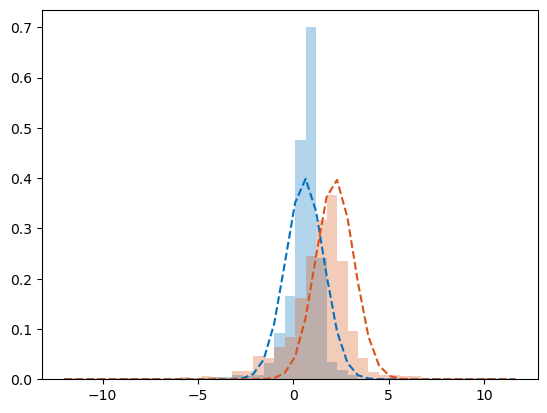

In [12]:
plt.plot(D3b_bins, w_E_norm0, linestyle='--',color=colorsmap[0])
plt.hist((SF3_w_E[:,iu2])/np.nanstd(SF3_w_E_std[:,iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[0], label='Eulerian')

plt.plot(D3b_bins, nw_E_norm0, linestyle='--',color=colorsmap[1])
plt.hist((SF3_w_E[:,iu2])/np.nanstd(SF3_nw_E_std[:,iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[1], label='Eulerian')
# plt.plot(D3b_bins, w_289_norm0, linestyle='--',color=colorsmap[3])
# plt.hist((w_sf3_289[:, iu])/np.std(w_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

# plt.plot(D3b_bins, w_625_norm0, linestyle='--',color=colorsmap[4])
# plt.hist((w_sf3_625[:, iu])/np.std(w_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

# plt.plot(D3b_bins, w_1089_norm0, linestyle='--',color=colorsmap[5])
# plt.hist((w_sf3_1089[:, iu])/np.std(w_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

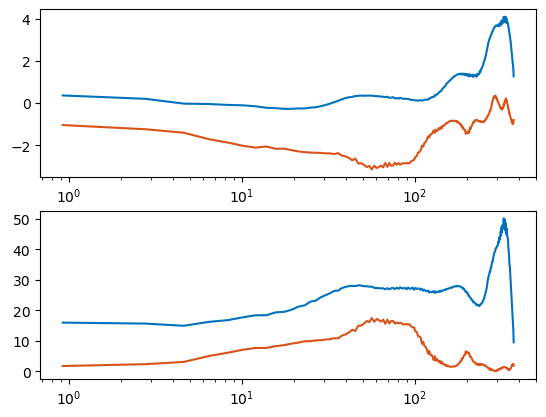

In [13]:
plt.subplot(2,1,1)
plt.semilogx(R*1e-3, skew(SF3_w_E, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul hf')
plt.semilogx(R*1e-3, skew(SF3_nw_E, axis=0), linewidth=1.5,color=colorsmap[1], label='Eul sm')

plt.subplot(2,1,2)
plt.semilogx(R*1e-3, kurtosis(SF3_w_E, fisher=True, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul hf')
plt.semilogx(R*1e-3, kurtosis(SF3_nw_E, fisher=True, axis=0), linewidth=1.5,color=colorsmap[1], label='Eul sm')


Text(0, 0.5, 'Kurtosis')

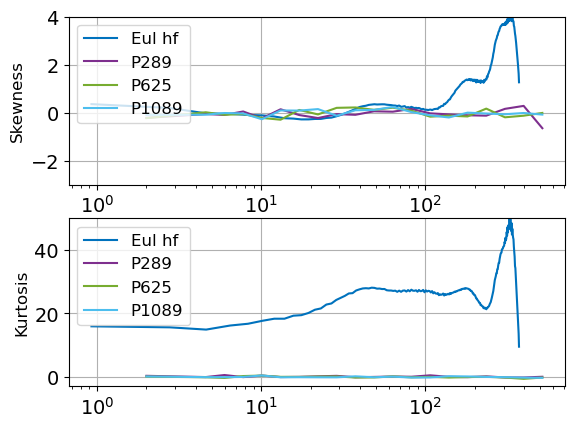

In [21]:
plt.subplot(2,1,1)
plt.semilogx(R*1e-3, skew(SF3_w_E, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul hf')
plt.semilogx(dist_axis*1e-3, skew(w_sf3_289, axis=0), linewidth=1.5,color=colorsmap[3], label='P289')
plt.semilogx(dist_axis*1e-3, skew(w_sf3_625, axis=0), linewidth=1.5,color=colorsmap[4], label='P625')
plt.semilogx(dist_axis*1e-3, skew(w_sf3_1089, axis=0), linewidth=1.5,color=colorsmap[5], label='P1089')
plt.legend()
plt.grid(True)
plt.ylabel('Skewness')
plt.ylim([-3,4])

plt.subplot(2,1,2)
plt.semilogx(R*1e-3, kurtosis(SF3_w_E, fisher=True, axis=0), linewidth=1.5,color=colorsmap[0], label='Eul hf')
plt.semilogx(dist_axis*1e-3, kurtosis(w_sf3_289, fisher=True, axis=0), linewidth=1.5,color=colorsmap[3], label='P289')
plt.semilogx(dist_axis*1e-3, kurtosis(w_sf3_625, fisher=True, axis=0), linewidth=1.5,color=colorsmap[4], label='P625')
plt.semilogx(dist_axis*1e-3, kurtosis(w_sf3_1089, fisher=True, axis=0), linewidth=1.5,color=colorsmap[5], label='P1089')
plt.legend()
plt.grid(True)
plt.ylim([-3,50])
plt.ylabel('Kurtosis')


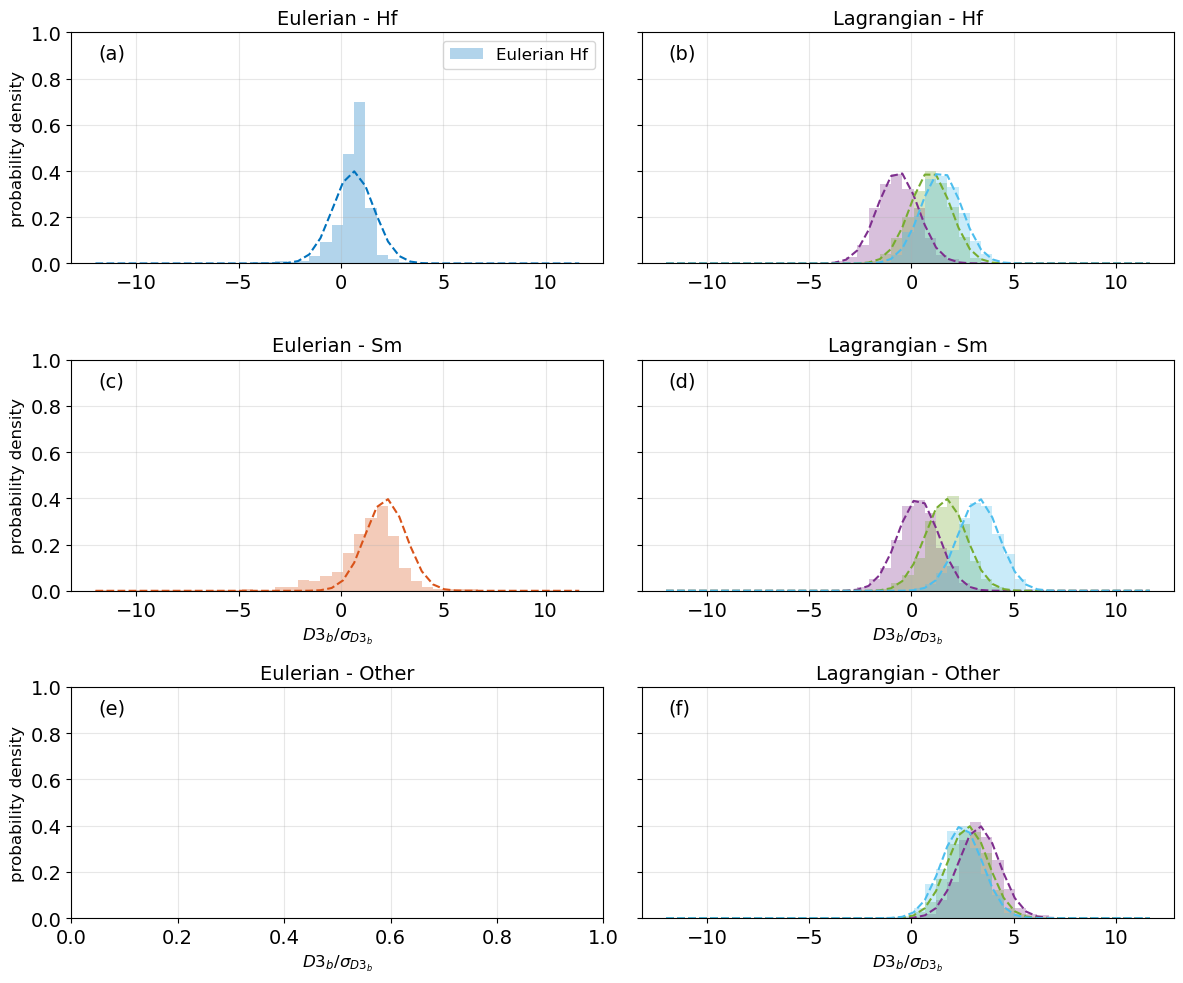

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 设置字体和样式
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# 创建3x2的子图
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# 给每个子图分配变量名
ax1, ax2 = axes[0, 0], axes[0, 1]  # 第一行
ax3, ax4 = axes[1, 0], axes[1, 1]  # 第二行
ax5, ax6 = axes[2, 0], axes[2, 1]  # 第三行

# 字母标签
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# ========== 第一列：欧拉部分 ==========

# 第一个子图 (a) - 欧拉 Hf
# 取消注释并添加您的欧拉数据
ax1.plot(D3b_bins, w_E_norm0, linestyle='--', color=colorsmap[0])
ax1.hist((SF3_w_E[:, iu2])/np.nanstd(SF3_w_E_std[:, iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[0], label='Eulerian Hf')
# ax1.plot(D3b_bins, nw_E_norm0, linestyle='--', color=colorsmap[1])
# ax1.hist((SF3_w_E[:, iu2])/np.nanstd(SF3_nw_E_std[:, iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[1], label='Eulerian Sm')

ax1.text(0.05, 0.95, labels[0], transform=ax1.transAxes, fontsize=14, va='top')
ax1.set_title('Eulerian - Hf')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylabel(r'probability density')
ax1.set_ylim([0,1])

# 第三个子图 (c) - 欧拉 Sm
# 取消注释并添加您的欧拉数据
ax3.plot(D3b_bins, nw_E_norm0, linestyle='--', color=colorsmap[1])
ax3.hist((SF3_w_E[:, iu2])/np.nanstd(SF3_nw_E_std[:, iu2]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[1], label='Eulerian Sm')

ax3.text(0.05, 0.95, labels[2], transform=ax3.transAxes, fontsize=14, va='top')
ax3.set_title('Eulerian - Sm')
ax3.grid(True, alpha=0.3)
ax3.set_ylabel(r'probability density')
ax3.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
ax3.set_ylim([0,1])

# ax3.axis('off')

# 第五个子图 (e) - 欧拉 其他（如果需要）
# 可以添加其他欧拉变量或留空
ax5.text(0.05, 0.95, labels[4], transform=ax5.transAxes, fontsize=14, va='top')
ax5.set_title('Eulerian - Other')
ax5.grid(True, alpha=0.3)
ax5.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
ax5.set_ylabel(r'probability density')
ax5.set_ylim([0,1])

# ========== 第二列：拉格朗日部分 ==========

# 第二个子图 (b) - P289, P625, P1089 (Hf)
ax2.plot(D3b_bins, w_289_norm0, linestyle='--', color=colorsmap[3])
ax2.hist((w_sf3_289[:, iu])/np.std(w_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

ax2.plot(D3b_bins, w_625_norm0, linestyle='--', color=colorsmap[4])
ax2.hist((w_sf3_625[:, iu])/np.std(w_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

ax2.plot(D3b_bins, w_1089_norm0, linestyle='--', color=colorsmap[5])
ax2.hist((w_sf3_1089[:, iu])/np.std(w_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

ax2.text(0.05, 0.95, labels[1], transform=ax2.transAxes, fontsize=14, va='top')
ax2.set_title('Lagrangian - Hf')
ax2.grid(True, alpha=0.3)
ax2.set_yticklabels('')
ax2.set_ylim([0,1])

# 第四个子图 (d) - P289, P625, P1089 (Sm)
ax4.plot(D3b_bins, nw_289_norm0, linestyle='--', color=colorsmap[3])
ax4.hist((nw_sf3_289[:, iu])/np.std(nw_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

ax4.plot(D3b_bins, nw_625_norm0, linestyle='--', color=colorsmap[4])
ax4.hist((nw_sf3_625[:, iu])/np.std(nw_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

ax4.plot(D3b_bins, nw_1089_norm0, linestyle='--', color=colorsmap[5])
ax4.hist((nw_sf3_1089[:, iu])/np.std(nw_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

ax4.text(0.05, 0.95, labels[3], transform=ax4.transAxes, fontsize=14, va='top')
ax4.set_title('Lagrangian - Sm')
ax4.grid(True, alpha=0.3)
ax4.set_yticklabels('')
ax4.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
ax4.set_ylim([0,1])

# 第六个子图 (f) - 其他拉格朗日变量
ax6.plot(D3b_bins, s_w_289_norm0, linestyle='--', color=colorsmap[3])
ax6.hist((s_w_sf3_289[:, iu])/np.std(s_w_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

ax6.plot(D3b_bins, s_w_625_norm0, linestyle='--', color=colorsmap[4])
ax6.hist((s_w_sf3_625[:, iu])/np.std(s_w_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

ax6.plot(D3b_bins, s_w_1089_norm0, linestyle='--', color=colorsmap[5])
ax6.hist((s_w_sf3_1089[:, iu])/np.std(s_w_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

ax6.text(0.05, 0.95, labels[5], transform=ax6.transAxes, fontsize=14, va='top')
ax6.set_title('Lagrangian - Other')
ax6.grid(True, alpha=0.3)
ax6.set_yticklabels('')
ax6.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
ax6.set_ylim([0,1])


plt.tight_layout()
plt.show()

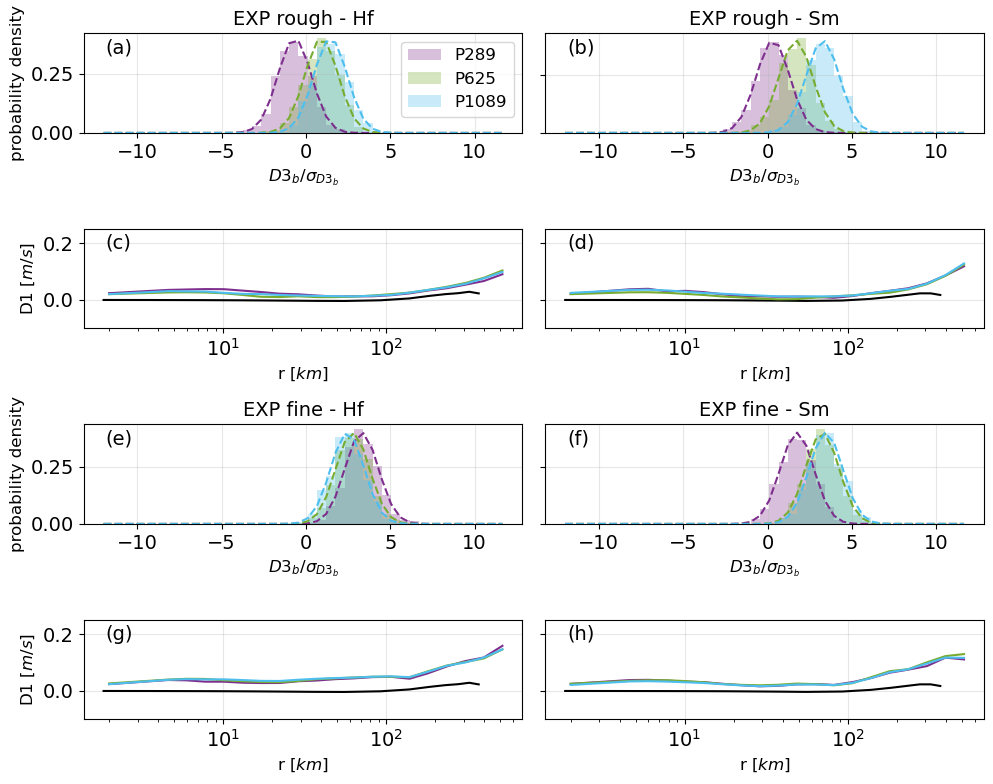

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 设置字体和样式
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# 创建4x2的子图（4行2列）
fig, axes = plt.subplots(4, 2, figsize=(10, 8))

# 给每个子图分配变量名，从ax1到ax8
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

# 字母标签 (a) 到 (h)
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

# ========== 第一个子图 (a) - EXP rough - Hf ==========
ax1.plot(D3b_bins, w_289_norm0, linestyle='--', color=colorsmap[3])
ax1.hist((w_sf3_289[:, iu])/np.std(w_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

ax1.plot(D3b_bins, w_625_norm0, linestyle='--', color=colorsmap[4])
ax1.hist((w_sf3_625[:, iu])/np.std(w_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

ax1.plot(D3b_bins, w_1089_norm0, linestyle='--', color=colorsmap[5])
ax1.hist((w_sf3_1089[:, iu])/np.std(w_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

ax1.text(0.05, 0.95, labels[0], transform=ax1.transAxes, fontsize=14, va='top')
ax1.set_title('EXP rough - Hf')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylabel(r'probability density')
ax1.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')

# ========== 第二个子图 (b) - EXP rough - Sm ==========
ax2.plot(D3b_bins, nw_289_norm0, linestyle='--', color=colorsmap[3])
ax2.hist((nw_sf3_289[:, iu])/np.std(nw_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

ax2.plot(D3b_bins, nw_625_norm0, linestyle='--', color=colorsmap[4])
ax2.hist((nw_sf3_625[:, iu])/np.std(nw_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

ax2.plot(D3b_bins, nw_1089_norm0, linestyle='--', color=colorsmap[5])
ax2.hist((nw_sf3_1089[:, iu])/np.std(nw_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

ax2.text(0.05, 0.95, labels[1], transform=ax2.transAxes, fontsize=14, va='top')
ax2.set_title('EXP rough - Sm')
ax2.grid(True, alpha=0.3)
ax2.set_yticklabels('')
ax2.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')


# ========== 第三个子图 (c) - 空着，等你添加内容 ==========
ax3.semilogx(R_check/1e3,SF1_E_HF,linestyle='-',linewidth=1.5,color='k',label='Eul')
ax3.semilogx(dist_axis/1e3,np.nanmean(w_SF1_289,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[3],label='P289')
ax3.semilogx(dist_axis/1e3,np.nanmean(w_SF1_625,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[4],label='P625')
ax3.semilogx(dist_axis/1e3,np.nanmean(w_SF1_1089,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[5],label='P1089')

ax3.text(0.05, 0.95, labels[2], transform=ax3.transAxes, fontsize=14, va='top')
ax3.grid(True, alpha=0.3)
ax3.set_ylabel(r'D1 [$m/s$]')
ax3.set_xlabel(r'r [$km$]')
ax3.set_ylim([-0.1,0.25])
# ax3.legend()



# ========== 第四个子图 (d)  ==========
ax4.semilogx(R_check/1e3,SF1_E_SM,linestyle='-',linewidth=1.5,color='k')
ax4.semilogx(dist_axis/1e3,np.nanmean(nw_SF1_289,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[3])
ax4.semilogx(dist_axis/1e3,np.nanmean(nw_SF1_625,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[4])
ax4.semilogx(dist_axis/1e3,np.nanmean(nw_SF1_1089,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[5])

ax4.text(0.05, 0.95, labels[3], transform=ax4.transAxes, fontsize=14, va='top')
ax4.set_xlabel(r'r [$km$]')
ax4.grid(True, alpha=0.3)
ax4.set_ylim([-0.1,0.25])
ax4.set_yticklabels('')

# ========== 第五个子图 (e) - EXP fine - Hf ==========
ax5.plot(D3b_bins, s_w_289_norm0, linestyle='--', color=colorsmap[3])
ax5.hist((s_w_sf3_289[:, iu])/np.std(s_w_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

ax5.plot(D3b_bins, s_w_625_norm0, linestyle='--', color=colorsmap[4])
ax5.hist((s_w_sf3_625[:, iu])/np.std(s_w_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

ax5.plot(D3b_bins, s_w_1089_norm0, linestyle='--', color=colorsmap[5])
ax5.hist((s_w_sf3_1089[:, iu])/np.std(s_w_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

ax5.text(0.05, 0.95, labels[4], transform=ax5.transAxes, fontsize=14, va='top')
ax5.set_title('EXP fine - Hf')
ax5.grid(True, alpha=0.3)
ax5.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')
ax5.set_ylabel(r'probability density')

# ========== 第六个子图 (f) - EXP fine - Sm ==========
ax6.plot(D3b_bins, s_nw_289_norm0, linestyle='--', color=colorsmap[3])
ax6.hist((s_nw_sf3_289[:, iu])/np.std(s_nw_sf3_289[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[3], label='P289')

ax6.plot(D3b_bins, s_nw_625_norm0, linestyle='--', color=colorsmap[4])
ax6.hist((s_nw_sf3_625[:, iu])/np.std(s_nw_sf3_625[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[4], label='P625')

ax6.plot(D3b_bins, s_nw_1089_norm0, linestyle='--', color=colorsmap[5])
ax6.hist((s_nw_sf3_1089[:, iu])/np.std(s_nw_sf3_1089[:, iu]), bins=D3b_bins, alpha=0.3, density=True, color=colorsmap[5], label='P1089')

ax6.text(0.05, 0.95, labels[5], transform=ax6.transAxes, fontsize=14, va='top')
ax6.set_title('EXP fine - Sm')
ax6.grid(True, alpha=0.3)
ax6.set_yticklabels('')
ax6.set_xlabel(r'$D3_{b}/\sigma_{D3_{b}}$')

# ==========  ==========
ax7.semilogx(R_check/1e3,SF1_E_HF,linestyle='-',linewidth=1.5,color='k',label='Eul')
ax7.semilogx(dist_axis/1e3,np.nanmean(w_SF1_289s,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[3],label='P289')
ax7.semilogx(dist_axis/1e3,np.nanmean(w_SF1_625s,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[4],label='P625')
ax7.semilogx(dist_axis/1e3,np.nanmean(w_SF1_1089s,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[5],label='P1089')
ax7.text(0.05, 0.95, labels[6], transform=ax7.transAxes, fontsize=14, va='top')
ax7.grid(True, alpha=0.3)
ax7.set_xlabel(r'r [$km$]')
ax7.grid(True, alpha=0.3)
ax7.set_ylim([-0.1,0.25])
ax7.set_ylabel(r'D1 [$m/s$]')

# ==========  ==========
ax8.semilogx(R_check/1e3,SF1_E_SM,linestyle='-',linewidth=1.5,color='k',label='Eul')
ax8.semilogx(dist_axis/1e3,np.nanmean(nw_SF1_289s,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[3],label='P289')
ax8.semilogx(dist_axis/1e3,np.nanmean(nw_SF1_625s,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[4],label='P625')
ax8.semilogx(dist_axis/1e3,np.nanmean(nw_SF1_1089s,axis=1),linestyle='-',linewidth=1.5,color=colorsmap[5],label='P1089')
ax8.text(0.05, 0.95, labels[7], transform=ax8.transAxes, fontsize=14, va='top')
ax8.set_xlabel(r'r [$km$]')
ax8.grid(True, alpha=0.3)
ax8.set_ylim([-0.1,0.25])
ax8.set_yticklabels('')

plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig4_Iceland_SF3PDF_SF1_E_L.png', dpi=300, bbox_inches='tight')

plt.show()


In [30]:
(np.tile(dist_axis,[1,1000])).shape

(1, 20000)